# This notebook shows how to compute atom-projection operators and apply them to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The atom-projection operator
The muffin-tin partition of the unit cell (one sphere per atom, plus the interstitial region between them) is exact, so for any two states $\psi_i,\psi_j$ of the same diagonalization
$$ (P_\alpha)_{ij}=\langle\psi_i|\hat P_\alpha|\psi_j\rangle=\int_{{\rm MT}_\alpha}\psi_i^*(\mathbf r)\,\psi_j(\mathbf r)\,d^3r, \qquad \sum_\alpha P_\alpha+P_{\rm interstitial}=\mathbb 1 $$
$P_\alpha$ is Hermitian and positive semi-definite (a Gram matrix restricted to a sub-volume); its diagonal is each state's fractional weight on atom $\alpha$'s muffin tin, its off-diagonal genuinely mixes two different eigenstates of the SAME diagonalization -- the piece that makes this an operator, not just a weight table.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}
si = Structure(SI_AVEC, SI_SPECIES).get_calculation("_scratch/si_atomproj", xc="PW", ngridk=(4, 4, 4))

proj = si.get_atom_projection((0.1, 0.2, 0.05), ist0=1, ist1=4)
proj.matrices.shape  # (natmtot, nst, nst)

(2, 4, 4)

### Applying $P_\alpha$ to a wavefunction: N vs. B character in monolayer h-BN
The more electronegative N pulls the bonding ($\pi$, valence-top) state's weight toward itself; the antibonding ($\pi^*$, conduction-bottom) state is B-dominated instead -- a sharp, sign-of-the-effect prediction. Shown below as a full band structure colored by weight on N, not just the two bands at K where the direct gap sits.

In [3]:
A, VACUUM = 4.743210000, 20.0  # Bohr, same hBN slab as 05_berry_curvature.ipynb
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation("_scratch/hbn_atomproj", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn.get_energy()

import re
first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 1.0 for o in occ)  # occupied count from EIGVAL.OUT, not an assumed electron count

In [4]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, K, M = (0, 0, 0), (1 / 3, 1 / 3, 0), (0.5, 0, 0)
# K' as the periodic image (2/3, -1/3, 0) -- hugs the BZ boundary instead of
# cutting through the interior near Gamma (same choice as 07_quantum_geometry.ipynb)
Kp = (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 7)] + [segment(a, b, 7)[1:] for a, b in [(K, M), (M, Kp), (Kp, G)]]
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

n, b = hbn.structure.atom_index("N"), hbn.structure.atom_index("B")
w0, w1 = ist1 - 3, ist1 + 3  # a few valence and conduction bands around the gap
efermi = float((hbn.workdir / "EFERMI.OUT").read_text().split()[0])
ha = 27.211386  # Hartree -> eV

energies, n_weight = [], []
with hbn.eigenstate_session() as session:
    for k in path:
        energies.append(session.get_eigenstates(k).energies[w0 - 1 : w1])
        n_weight.append(session.atom_projection(k, w0, w1).matrices[n].diagonal().real)
energies = (np.array(energies) - efermi) * ha
n_weight = np.array(n_weight)

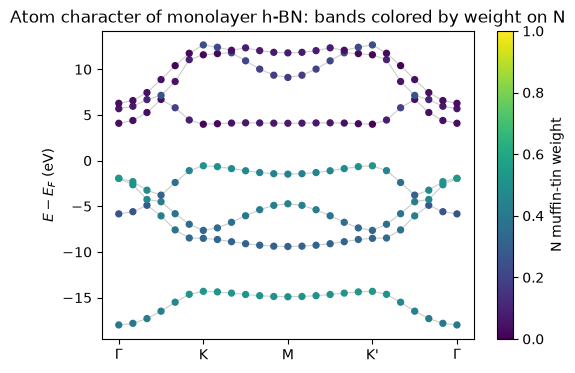

In [5]:
x = np.arange(len(path))
fig, ax = plt.subplots(figsize=(6, 4))
for band in range(energies.shape[1]):
    ax.plot(x, energies[:, band], color="0.8", linewidth=0.8, zorder=1)
sc = ax.scatter(
    np.tile(x, energies.shape[1]), energies.T.ravel(), c=n_weight.T.ravel(),
    cmap="viridis", vmin=0, vmax=1, s=18, zorder=2,
)
ax.set_xticks(ticks)
ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
ax.set_ylabel(r"$E-E_F$ (eV)")
fig.colorbar(sc, ax=ax, label="N muffin-tin weight")
ax.set_title("Atom character of monolayer h-BN: bands colored by weight on N")
plt.show()